In [2]:
import crabnet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

print("Ready to go! 🚀")

Ready to go! 🚀


In [3]:
merged_O_OH = pd.read_csv('merged_700_data.csv')

In [4]:
merged_O_OH.head()

,Products,Sites,Facet,surfaceComposition,ChemicalComposition,Reaction_Energy,Site
0,O*,"{""O"": ""hollow|A_A_A|FCC""}",111,Ag,Ag12,1.961800,hollow|A_A_A|FCC
1,O*,"{""O"": ""hollow|A_A_A|HCP""}",111,Ag,Ag12,2.050681,hollow|A_A_A|HCP
2,O*,"{""O"": ""top|A""}",111,Ag,Ag12,3.426808,top|A
3,OH*,"{""OH"": ""bridge|A_A|A""}",111,Ag,Ag12,0.718151,bridge|A_A|A
4,OH*,"{""OH"": ""hollow|A_A_A|FCC""}",111,Ag,Ag12,0.563018,hollow|A_A_A|FCC


<Axes: >

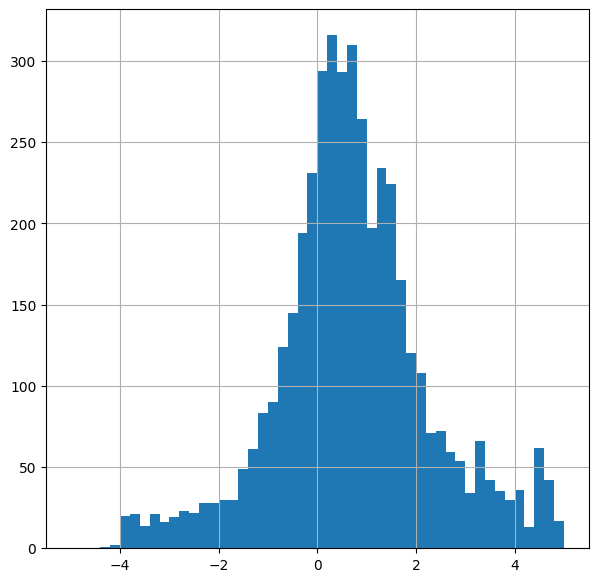

In [5]:
merged_O_OH["Reaction_Energy"].hist(figsize = (7, 7), range = (-5, 5), bins = 50)

In [6]:
print("maximum is" , merged_O_OH["Reaction_Energy"].max())
print("minimum is" , merged_O_OH["Reaction_Energy"].min())
print("average is" , merged_O_OH["Reaction_Energy"].mean())
print("standard deviation is" , merged_O_OH["Reaction_Energy"].std())

maximum is 6.00841663
minimum is -5.08255209164781
average is 0.7350736360269167
standard deviation is 1.6082484451285994


In [7]:
merged_O_OH["ChemicalComposition"].unique()

array(['Ag12', 'Ag12O18', 'Ag16', 'Ag27', 'Ag28O16', 'Ag36', 'Ag3Au9',
       'Ag3Bi9', 'Ag3Cd9', 'Ag3Cu9', 'Ag3Ir9', 'Ag3Os9', 'Ag3Pd9',
       'Ag3Pt9', 'Ag3Re9', 'Ag3Rh9', 'Ag3Ru9', 'Ag3Tc9', 'Ag3Zn9', 'Ag64',
       'Ag6Au6', 'Ag6Bi6', 'Ag6Cu6', 'Ag6Ir6', 'Ag6O12', 'Ag6Pd6',
       'Ag6Pt6', 'Ag6Re6', 'Ag6Rh6', 'Ag6Ru6', 'Ag6Zn6', 'Ag8O16',
       'Ag8O8', 'Ag9Al3', 'Ag9Au3', 'Ag9Bi3', 'Ag9Cu3', 'Ag9Ga3',
       'Ag9Ir3', 'Ag9Os3', 'Ag9Pd3', 'Ag9Pt3', 'Ag9Re3', 'Ag9Rh3',
       'Ag9Ru3', 'Ag9Sc3', 'Ag9Tc3', 'Ag9Y3', 'Ag9Zn3', 'Al12', 'Al3Co9',
       'Al3Cu9', 'Al3Fe9', 'Al3Hf9', 'Al3Ir9', 'Al3La9', 'Al3Nb9',
       'Al3Pd9', 'Al3Rh9', 'Al3Ru9', 'Al3Sc9', 'Al3Ta9', 'Al3Ti9',
       'Al3V9', 'Al9Co3', 'Al9Cu3', 'Al9Hf3', 'Al9Ir3', 'Al9La3',
       'Al9Mo3', 'Al9Nb3', 'Al9Ni3', 'Al9Pd3', 'Al9Pt3', 'Al9Rh3',
       'Al9Ru3', 'Al9Sc3', 'Al9Ta3', 'Al9Ti3', 'Al9V3', 'Al9Y3', 'Al9Zr3',
       'Au12', 'Au12O18', 'Au16', 'Au27', 'Au32O48', 'Au36', 'Au3Bi9',
       'Au3Cu9', 'Au3Hf9', 'Au3Ir

In [137]:
train_df, test_df = train_test_split(
    merged_O_OH, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # for reproducibility
    shuffle=True
)

In [138]:
train_df = pd.DataFrame({"formula" : train_df["ChemicalComposition"], 
                         "target" : train_df["Reaction_Energy"]})
test_df = pd.DataFrame({"formula" : test_df["ChemicalComposition"], 
                         "target" : test_df["Reaction_Energy"]})

In [139]:
from crabnet.crabnet_ import CrabNet

cb = CrabNet(
    verbose=True,       # optional, for logging
    learningcurve=False, # optional, skip learning curve plotting
    epochs = 258
)


Model architecture: out_dims, d_model, N, heads
3, 512, 3, 4
Running on compute device: cpu


Model size: 11987206 parameters



Generating EDM: 100%|█████████████| 2835/2835 [00:00<00:00, 299683.75formulae/s]


loading data with up to 7 elements in the formula
training with batchsize 128 (2**7.000)


Generating EDM: 100%|███████████████| 709/709 [00:00<00:00, 388473.09formulae/s]

loading data with up to 7 elements in the formula
stepping every 230 training passes, cycling lr every 10 epochs
checkin at 20 epochs to match lr scheduler
258 epochs not divisible by 20 (2*epochs_step), updating epochs to 260 for learning


Epoch: 0/260 --- train mae: 1.16 val mae: 1.11


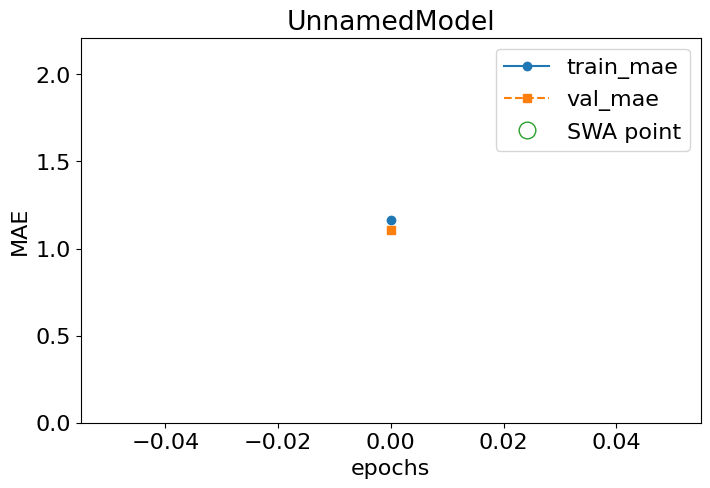

Epoch: 19/260 --- train mae: 0.646 val mae: 0.738


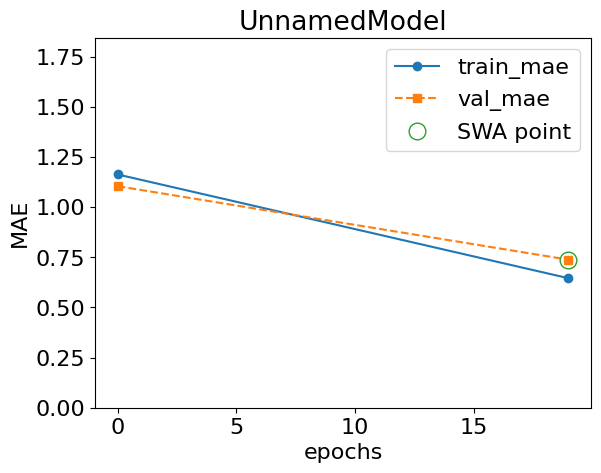

Epoch 39 failed to improve.
Discarded: 1/3 weight updates
Epoch: 39/260 --- train mae: 0.61 val mae: 0.773


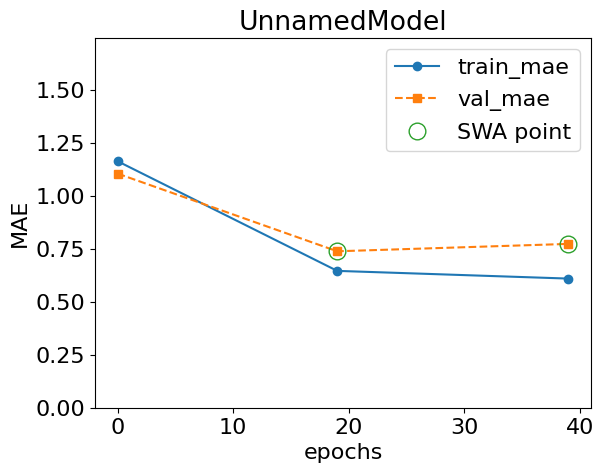

Epoch 59 failed to improve.
Discarded: 2/3 weight updates
Epoch: 59/260 --- train mae: 0.596 val mae: 0.784


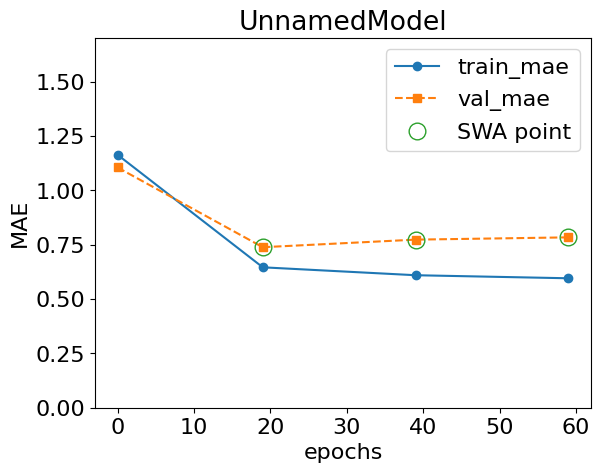

Epoch 79 failed to improve.
Discarded: 3/3 weight updates
Epoch: 79/260 --- train mae: 0.586 val mae: 0.799


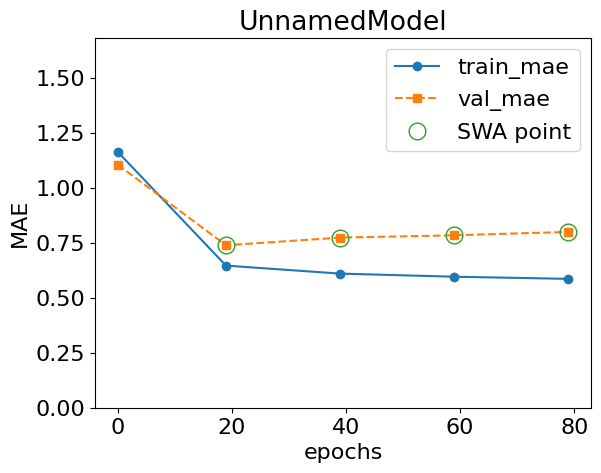

Discarded: 3/3weight updates, early-stopping now
Saving network (UnnamedModel) to models/trained_models/UnnamedModel.pth


In [140]:
cb.fit(train_df)

In [141]:
y_pred = cb.predict(test_df)

Generating EDM: 100%|███████████████| 887/887 [00:00<00:00, 373941.87formulae/s]


loading data with up to 7 elements in the formula


In [142]:
print(y_pred)

[ 2.849756    1.12196875 -1.29821515  0.62961346  1.62503648  0.13891214
 -2.31880879  1.11011243  1.36557174  0.11345798  1.15867424 -1.5855813
  0.51544046 -0.92820162  4.11368752  1.15157688  1.50720799  1.44614482
  0.9441489   0.54785579  0.54792482  1.62503648  3.45489335 -0.98524243
 -1.39755344 -0.46080023  0.19831795  0.79745656 -0.87376732  0.79465079
  0.35282496 -2.00542164  0.27840182  0.49779245 -3.1306653   0.51791304
  0.13891214  1.34292865  2.79671645  1.34938431  0.98573303  4.06502008
  4.11368752 -1.37518072  0.56940156  0.09283477 -0.19922996  1.67974687
  1.24790871  3.0221827   0.01054698 -0.51284665  1.81889796  1.17631793
  0.09011739  2.92856264 -0.08243173  0.09283477  0.03240585  0.83529812
  2.90183353  1.63814342  3.60664344  0.27840182  1.0615387   0.09283477
  1.11011243 -1.22045517 -2.43619466  0.09283477  2.832587    0.87365985
  0.09283477  0.17321318  0.3332592  -0.02536505  2.99449396  1.55785775
  2.33437872  0.38824159  0.81123757  0.49053243 -1.

In [143]:
test_df["predicted"] = y_pred
test_df.head(10)

,formula,target,count,predicted
2547,La12O18,4.328494,2,2.849756
842,Bi3Pd9,1.784915,2,1.121969
4081,Ta8O16,-1.071636,2,-1.298215
964,Bi9Pt3,0.398463,2,0.629613
318,Ag9Pt3,1.692530,2,1.625036
2917,Os3Ru9,0.521531,2,0.138912
4337,WC26N4,-1.477885,3,-2.318809
2341,Ir3Pt9,1.943054,2,1.110112
151,Ag6Au6,0.908332,2,1.365572
2446,Ir9La3,-0.411031,2,0.113458


MAE     = 0.685
RMSE    = 0.966
R²      = 0.645
Pearson R = 0.807


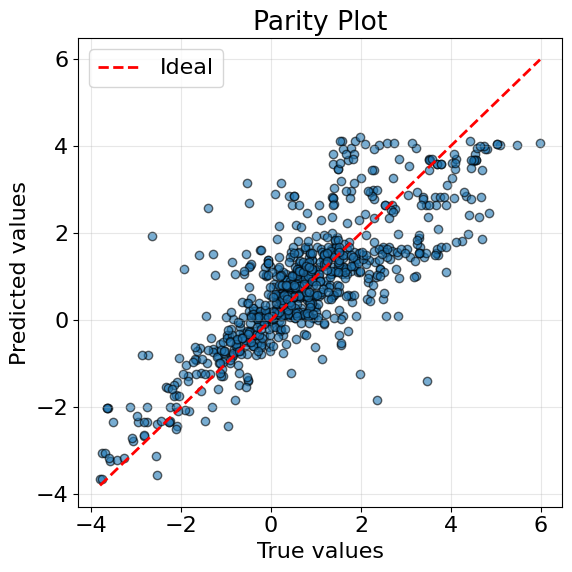

In [144]:
from scipy.stats import pearsonr
from sklearn.metrics import r2_score

# --- Metrics ---
y_true = test_df["target"].values
y_pred = test_df["predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [145]:
print("Maximum: ", test_df["target"].max())
print("Minimum: ", test_df["target"].min())
print("Mean: ", test_df["target"].mean())
print("STD: ", test_df["target"].std())

Maximum:  5.98221280999999
Minimum:  -3.80586931906163
Mean:  0.7309473663200843
STD:  1.622089091012585


## The following is to produce more data based on known O or OH energy ##
### This is done again using Crabnet with a "load" on knowning O or OH, then use that to predict the corresponding OH or O energy 



In [22]:
null_O_OH = pd.read_csv('merged_2500_data.csv')

In [23]:
null_O_OH.head(20)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
0,Ag,100,Ag64,hollow,NaN,NaN
1,Ag,111,Ag12,bridge|A_A|A,NaN,0.718151
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955
4,Ag,111,Ag12,top|A,3.426808,1.387435
5,Ag,111,Ag16,bridge,NaN,NaN
6,Ag,111,Ag16,ontop,NaN,NaN
7,Ag,111,Ag36,NaN,NaN,NaN
8,Ag,211,Ag36,ontop,NaN,NaN
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049


In [24]:
null_OH = null_O_OH[null_O_OH["O*_energy"].notnull()]
null_OH.head(10)

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955
4,Ag,111,Ag12,top|A,3.426808,1.387435
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049
19,Ag2O,110,Ag28O16,peroxo,3.572220,NaN
20,Ag3Al,111,Ag9Al3,hollow|A_A_A|FCC,2.246670,NaN
21,Ag3Al,111,Ag9Al3,hollow|A_A_A|HCP,2.346134,NaN
22,Ag3Al,111,Ag9Al3,hollow|A_A_B|FCC,-0.078674,NaN
23,Ag3Al,111,Ag9Al3,hollow|A_A_B|HCP,-0.105450,NaN
24,Ag3Al,111,Ag9Al3,top|B,0.695832,NaN


In [25]:
toPredict_OH_null = null_OH[null_OH["OH*_energy"].isnull()]
print(toPredict_OH_null.shape)
toPredict_OH_null.head(10)

(911, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
19,Ag2O,110,Ag28O16,peroxo,3.572220,NaN
20,Ag3Al,111,Ag9Al3,hollow|A_A_A|FCC,2.246670,NaN
21,Ag3Al,111,Ag9Al3,hollow|A_A_A|HCP,2.346134,NaN
22,Ag3Al,111,Ag9Al3,hollow|A_A_B|FCC,-0.078674,NaN
23,Ag3Al,111,Ag9Al3,hollow|A_A_B|HCP,-0.105450,NaN
24,Ag3Al,111,Ag9Al3,top|B,0.695832,NaN
25,Ag3Au,111,Ag9Au3,bridge|A_A|B,2.571306,NaN
42,Ag3Ga,111,Ag9Ga3,hollow|A_A_B|HCP,0.823293,NaN
43,Ag3Ga,111,Ag9Ga3,top|B,1.687590,NaN
44,Ag3Ir,111,Ag9Ir3,hollow-tilt|A_A_B|FCC,0.642869,NaN


In [50]:
train_OH_null = null_OH[null_OH["OH*_energy"].notnull()]
print(train_OH_null.shape)
train_OH_null.head(10)

(698, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
2,Ag,111,Ag12,hollow|A_A_A|FCC,1.961800,0.563018
3,Ag,111,Ag12,hollow|A_A_A|HCP,2.050681,0.589955
4,Ag,111,Ag12,top|A,3.426808,1.387435
9,Ag-fcc,111,Ag16,fcc,2.258668,0.718049
26,Ag3Au,111,Ag9Au3,hollow|A_A_A|FCC,2.208363,0.660700
27,Ag3Au,111,Ag9Au3,hollow|A_A_A|HCP,2.311256,0.726588
28,Ag3Au,111,Ag9Au3,hollow|A_A_B|FCC,2.103282,0.857080
29,Ag3Au,111,Ag9Au3,hollow|A_A_B|HCP,2.225204,1.001232
30,Ag3Au,111,Ag9Au3,top|B,3.294765,1.723517
32,Ag3Bi,111,Ag9Bi3,hollow|A_A_A|FCC,1.938454,0.489942


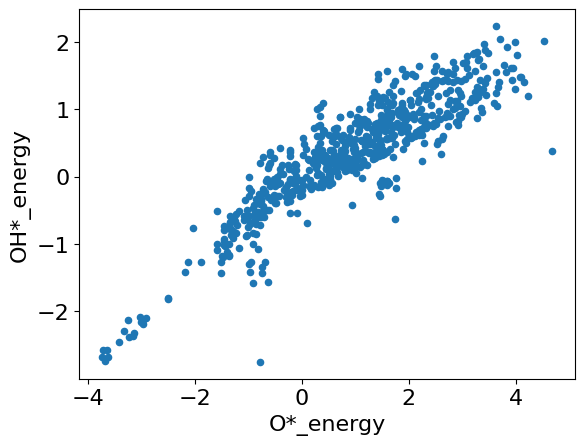

In [156]:
train_OH_null.plot.scatter(x="O*_energy", y="OH*_energy")
plt.show()

In [106]:
train_OH_null_afterHeldout, heldout_true_label = train_test_split(
    train_OH_null, 
    test_size=0.2,     
    random_state=42,    
    shuffle=True
)

train_OH_null_afterHeldout.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
266,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781
113,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114
752,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317
2007,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129
1957,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044


In [107]:
train_df_OH, test_df_OH = train_test_split(
    train_OH_null_afterHeldout, 
    test_size=0.2,      # 20% for testing
    random_state=18,    # for reproducibility
    shuffle=True
)

train_df_OH.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
1151,Li0.5CoO2,10-14,Co36Li18O77,NaN,3.294541,1.183651
40,Ag3Cu,111,Ag9Cu3,hollow|A_A_B|HCP,1.442969,0.318513
1280,Os3Pd,111,Os9Pd3,hollow|A_A_A|FCC,-0.378574,0.168236
2140,RuTc,101,Ru6Tc6,hollow|A_B_B|HCP,-1.080540,-0.648030
52,Ag3Os,111,Ag9Os3,top|B,-0.797905,-0.600763


In [108]:
print("held out dataset:" , heldout_true_label.shape)
print("Training dataset:" , train_df_OH.shape)

held out dataset: (140, 6)
Training dataset: (446, 6)


In [109]:
train_df_OH = pd.DataFrame({"formula" : train_df_OH["ChemicalComposition"], 
                            "load" : train_df_OH["O*_energy"],
                         "target" : train_df_OH["OH*_energy"]})
test_df_OH = pd.DataFrame({"formula" : test_df_OH["ChemicalComposition"], 
                            "load" : test_df_OH["O*_energy"],
                         "target" : test_df_OH["OH*_energy"]})

In [110]:
cb_OH_from_O = CrabNet(
    verbose=True,       # optional, for logging
    learningcurve=False, # optional, skip learning curve plotting
    extend_features=["load"],
    d_model = 128
)


Model architecture: out_dims, d_model, N, heads
3, 128, 3, 4
Running on compute device: cpu


Model size: 3445510 parameters



Generating EDM: 100%|███████████████| 356/356 [00:00<00:00, 351086.81formulae/s]


loading data with up to 7 elements in the formula
training with batchsize 128 (2**7.000)


Generating EDM: 100%|█████████████████| 90/90 [00:00<00:00, 282128.07formulae/s]

loading data with up to 7 elements in the formula
stepping every 30 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.626 val mae: 0.628


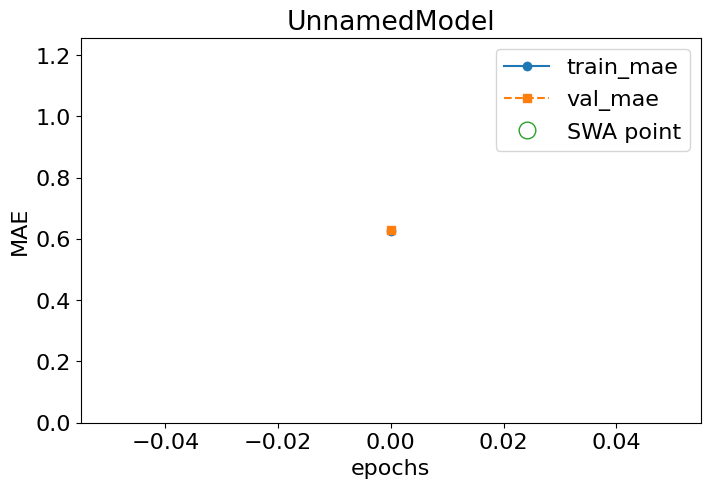

Epoch: 19/300 --- train mae: 0.361 val mae: 0.465


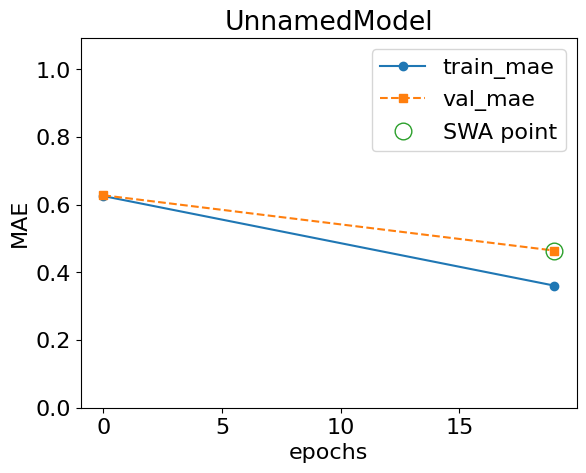

Epoch: 39/300 --- train mae: 0.322 val mae: 0.44


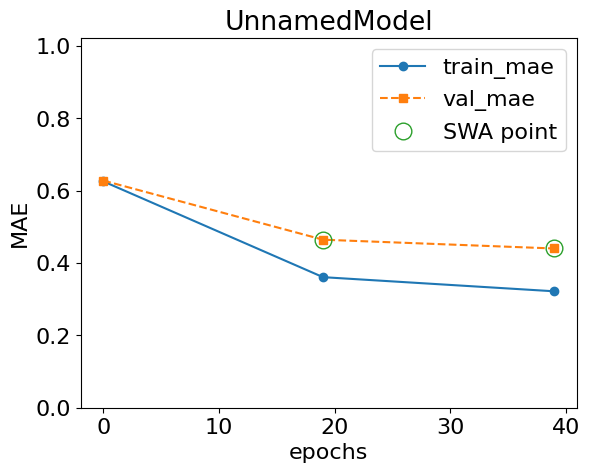

Epoch: 59/300 --- train mae: 0.28 val mae: 0.442


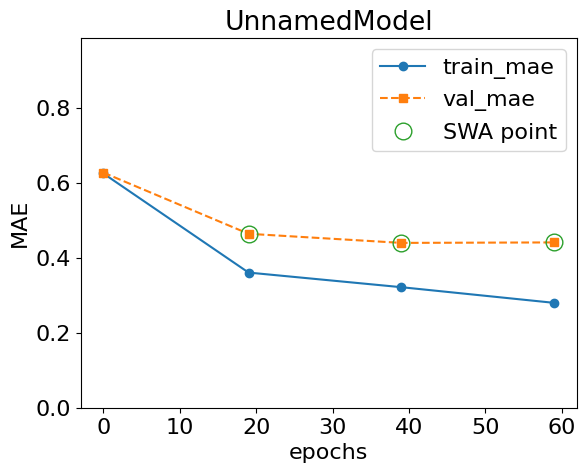

Epoch: 79/300 --- train mae: 0.264 val mae: 0.438


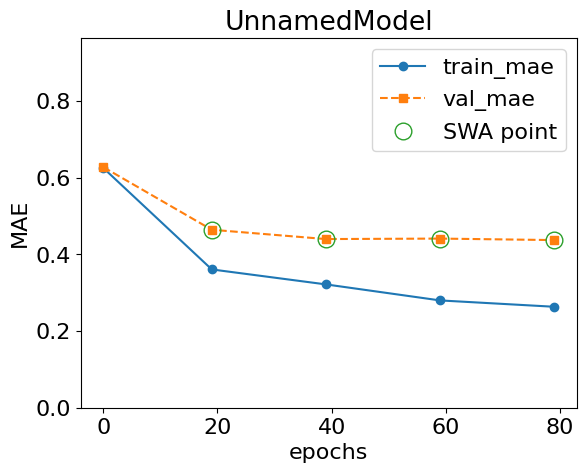

Epoch 99 failed to improve.
Discarded: 1/3 weight updates
Epoch: 99/300 --- train mae: 0.252 val mae: 0.457


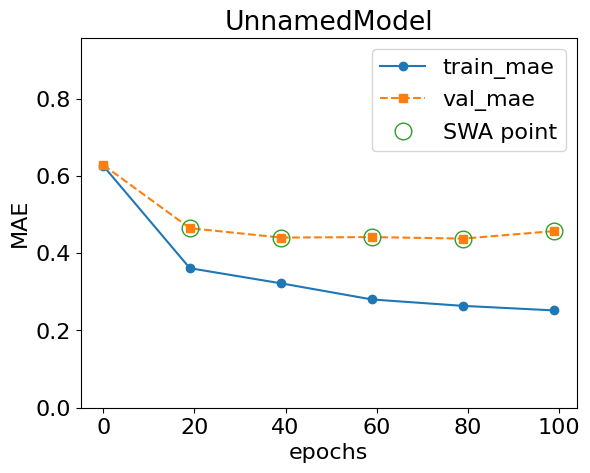

Epoch 119 failed to improve.
Discarded: 2/3 weight updates
Epoch: 119/300 --- train mae: 0.235 val mae: 0.471


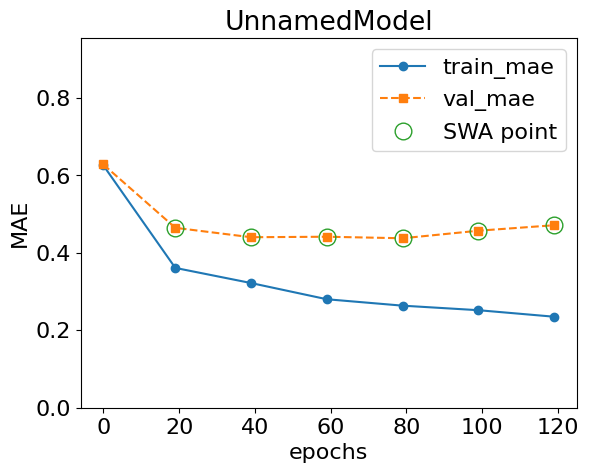

Epoch 139 failed to improve.
Discarded: 3/3 weight updates
Epoch: 139/300 --- train mae: 0.227 val mae: 0.467


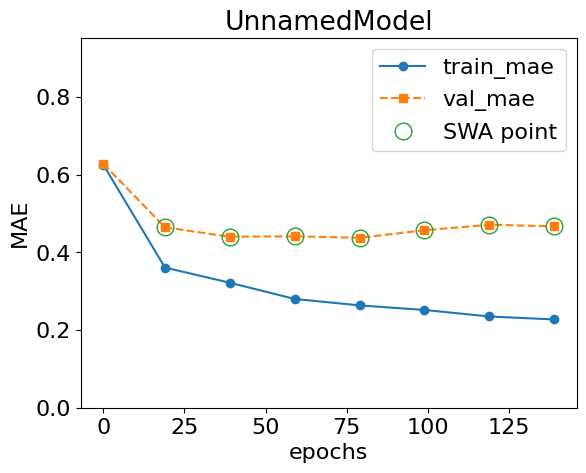

Discarded: 3/3weight updates, early-stopping now
Saving network (UnnamedModel) to models/trained_models/UnnamedModel.pth


In [111]:
cb_OH_from_O.fit(train_df_OH)

In [112]:
y_pred = cb_OH_from_O.predict(test_df_OH)

Generating EDM: 100%|███████████████| 112/112 [00:00<00:00, 341396.84formulae/s]

loading data with up to 7 elements in the formula


In [113]:
test_df_OH["predicted"] = y_pred
test_df_OH.head(10)

,formula,load,target,count,predicted
958,Ag3Ir9,0.335997,1.025653,2,0.875055
2350,Co9CrFeMnNiZnO20,3.225822,1.827501,7,1.259183
1769,Au3Re9,-1.515123,-1.426799,2,-0.650470
2185,Ta12,-3.260459,-2.127228,1,-1.771987
1610,Au3Pt9,1.420026,1.443954,2,1.267668
2218,Pd3Tc9,-1.511656,-1.267727,2,-0.863684
1472,Pd9Ru3,0.473007,-0.069796,2,0.751453
2112,Ru9Tc3,-0.772597,-0.330361,2,-0.245553
2072,Os3Ru9,1.229308,0.359027,2,0.228018
299,Au9Os3,-0.274333,-0.377524,2,1.148797


MAE     = 0.333
RMSE    = 0.503
R²      = 0.666
Pearson R = 0.826


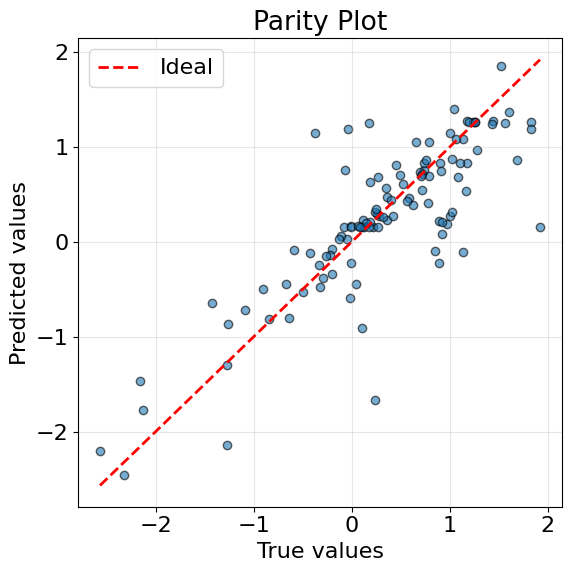

In [114]:
y_true = test_df_OH["target"].values
y_pred = test_df_OH["predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [115]:
print("Maximum: ", test_df_OH["target"].max())
print("Minimum: ", test_df_OH["target"].min())
print("Mean: ", test_df_OH["target"].mean())
print("STD: ", test_df_OH["target"].std())

Maximum:  1.919074819784214
Minimum:  -2.5678463209197844
Mean:  0.32666957629314375
STD:  0.8740781651631868


## Now I have the pseudo labelled OH data and now I will use this pseudo data + true labelled data to see if the pseudo data actually increases the performance

In [116]:
toPredict_OH = pd.DataFrame({"formula" : toPredict_OH_null["ChemicalComposition"],
                             "load" : toPredict_OH_null["O*_energy"],
                            "target" : toPredict_OH_null["OH*_energy"]})
OH_pred = cb_OH_from_O.predict(toPredict_OH)
toPredict_OH["predicted(OH*)"] = OH_pred
toPredict_OH.head(10)

Generating EDM: 100%|███████████████| 911/911 [00:00<00:00, 443324.16formulae/s]

loading data with up to 7 elements in the formula


,formula,load,target,count,predicted(OH*)
19,Ag28O16,3.572220,NaN,2,0.195090
20,Ag9Al3,2.246670,NaN,2,0.801330
21,Ag9Al3,2.346134,NaN,2,0.801330
22,Ag9Al3,-0.078674,NaN,2,0.801330
23,Ag9Al3,-0.105450,NaN,2,0.801330
24,Ag9Al3,0.695832,NaN,2,0.801330
25,Ag9Au3,2.571306,NaN,2,0.793605
42,Ag9Ga3,0.823293,NaN,2,0.748285
43,Ag9Ga3,1.687590,NaN,2,0.748285
44,Ag9Ir3,0.642869,NaN,2,0.787276


In [117]:
print("pseudo label after leaving out 70: ", train_OH_null_afterHeldout.shape)
train_OH_null_afterHeldout.head()

pseudo label after leaving out 70:  (558, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
266,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781
113,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114
752,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317
2007,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129
1957,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044


This is the true label data, so it will be concatanated with the pseudo label data below

In [118]:
test_df_OH.head()

,formula,load,target,count,predicted
958,Ag3Ir9,0.335997,1.025653,2,0.875055
2350,Co9CrFeMnNiZnO20,3.225822,1.827501,7,1.259183
1769,Au3Re9,-1.515123,-1.426799,2,-0.650470
2185,Ta12,-3.260459,-2.127228,1,-1.771987
1610,Au3Pt9,1.420026,1.443954,2,1.267668


In [119]:
true_label_train = pd.DataFrame({"formula": train_OH_null_afterHeldout["ChemicalComposition"],
                                "target" : train_OH_null_afterHeldout["O*_energy"] - train_OH_null_afterHeldout["OH*_energy"]})

pseudo_label = pd.DataFrame({
    "formula" : toPredict_OH["formula"],
    "target" : toPredict_OH["load"] - toPredict_OH["predicted(OH*)"]
})

In [120]:
train_pseudo_true = pd.concat([true_label_train, pseudo_label])
print(train_pseudo_true.shape)
train_pseudo_true.head()

(1469, 2)


,formula,target
266,Au9Bi3,0.885535
113,Ag6Bi6,0.920185
752,Cu9Zn3,0.741607
2007,Rh6Zn6,1.842880
1957,Rh9Ru3,0.132928


In [121]:
cb_pseudo_true = CrabNet(
    verbose=True,       # optional, for logging
    learningcurve=False, # optional, skip learning curve plotting
    d_model = 256
)


Model architecture: out_dims, d_model, N, heads
3, 256, 3, 4
Running on compute device: cpu


Model size: 5899526 parameters



Generating EDM: 100%|█████████████| 1175/1175 [00:00<00:00, 404888.86formulae/s]


loading data with up to 7 elements in the formula
training with batchsize 128 (2**7.000)


Generating EDM: 100%|███████████████| 294/294 [00:00<00:00, 337103.71formulae/s]

loading data with up to 7 elements in the formula
stepping every 100 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 1.05 val mae: 1.03


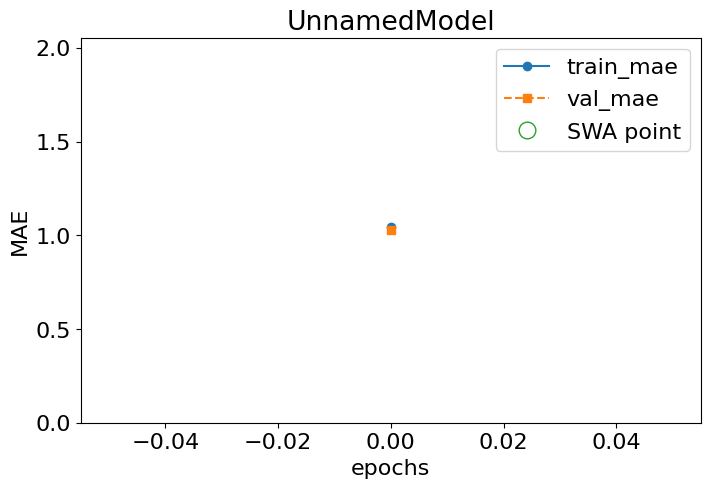

Epoch: 19/300 --- train mae: 0.54 val mae: 0.496


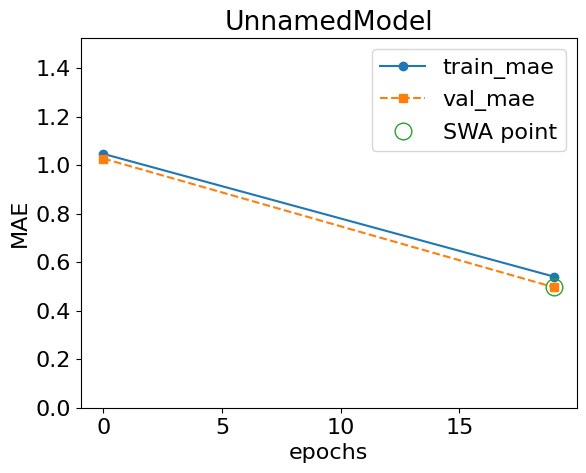

Epoch: 39/300 --- train mae: 0.492 val mae: 0.481


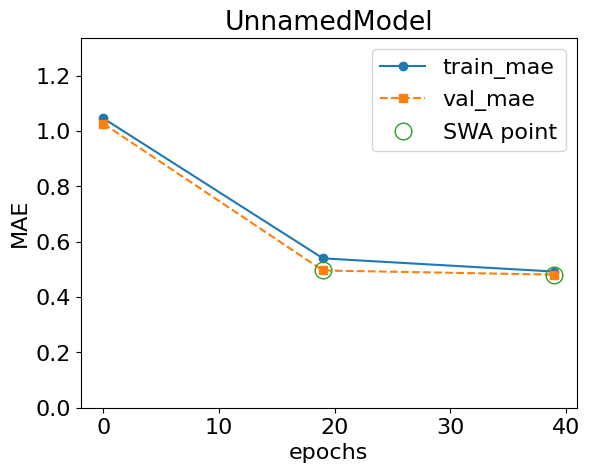

Epoch 59 failed to improve.
Discarded: 1/3 weight updates
Epoch: 59/300 --- train mae: 0.468 val mae: 0.499


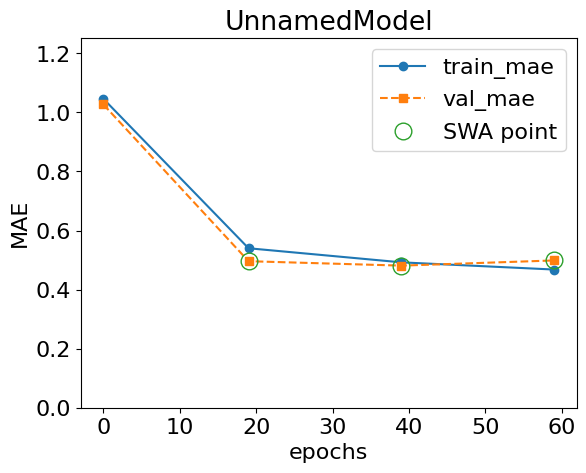

Epoch 79 failed to improve.
Discarded: 2/3 weight updates
Epoch: 79/300 --- train mae: 0.452 val mae: 0.522


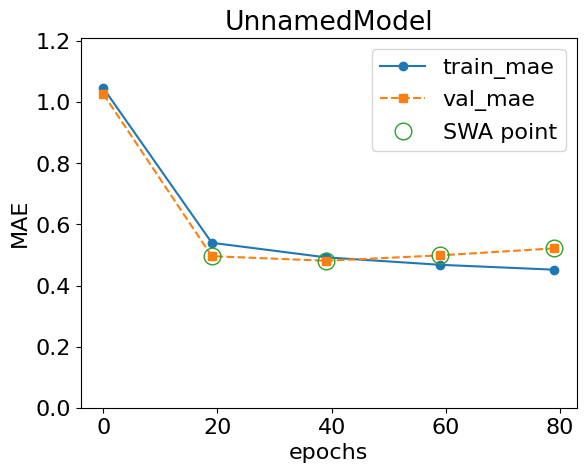

Epoch 99 failed to improve.
Discarded: 3/3 weight updates
Epoch: 99/300 --- train mae: 0.443 val mae: 0.553


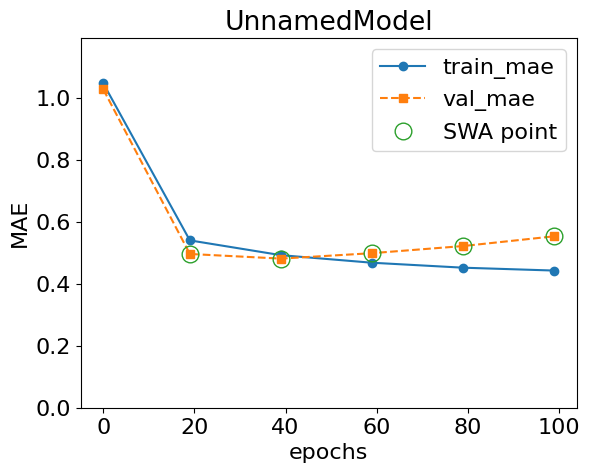

Discarded: 3/3weight updates, early-stopping now
Saving network (UnnamedModel) to models/trained_models/UnnamedModel.pth


In [122]:
cb_pseudo_true.fit(train_pseudo_true)

In [123]:
heldout_true_label.head()
heldout_toPred = pd.DataFrame({"formula" : heldout_true_label["ChemicalComposition"],
                              "target" : heldout_true_label["O*_energy"] - heldout_true_label["OH*_energy"]})

In [124]:
held_out_eval = cb_pseudo_true.predict(heldout_toPred)

Generating EDM: 100%|███████████████| 140/140 [00:00<00:00, 334779.11formulae/s]

loading data with up to 7 elements in the formula


In [125]:
heldout_toPred["predicted"] = held_out_eval

In [126]:
heldout_toPred.head()

,formula,target,count,predicted
506,Bi6Ru6,0.891019,2,0.556701
1817,Re9Tc3,-0.759546,2,-0.422123
1415,Cu3Pd9,1.301226,2,0.934453
500,Bi6Rh6,1.039940,2,0.723550
1121,La12,-0.806931,1,-0.330014


MAE     = 0.368
RMSE    = 0.498
R²      = 0.697
Pearson R = 0.837


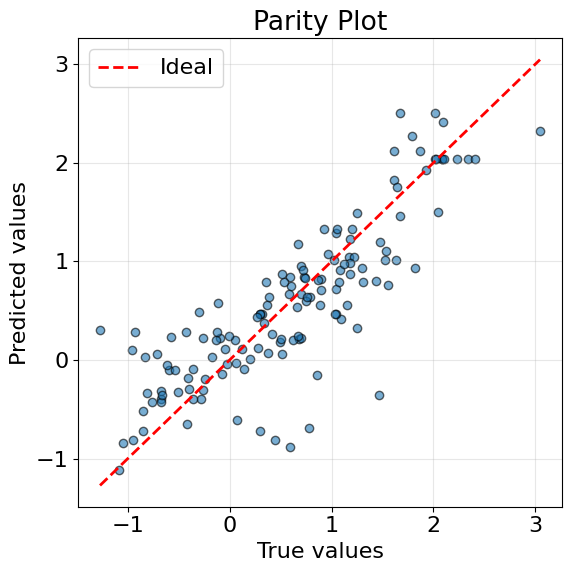

In [127]:
y_true = heldout_toPred["target"].values
y_pred = heldout_toPred["predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [128]:
print("Maximum: ", heldout_toPred["target"].max())
print("Minimum: ", heldout_toPred["target"].min())
print("Mean: ", heldout_toPred["target"].mean())
print("STD: ", heldout_toPred["target"].std())

Maximum:  3.044749469999946
Minimum:  -1.2710359851219577
Mean:  0.5905428631337643
STD:  0.9073220774725311


### The accuracy matrix in this case cannot be compared with models using ONLY true labels, so the following re-trains the Crabnet models of using only true labels after leaving out the held out set

In [129]:
print(train_OH_null_afterHeldout.shape)
train_OH_null_afterHeldout.head()

(558, 6)


,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
266,Au3Bi,111,Au9Bi3,hollow|A_A_A|HCP,2.021316,1.135781
113,AgBi,101,Ag6Bi6,hollow|A_B_B|FCC,1.280299,0.360114
752,Cu3Zn,111,Cu9Zn3,hollow|A_A_A|FCC,0.981924,0.240317
2007,RhZn,101,Rh6Zn6,top|B,2.863009,1.020129
1957,Rh3Ru,111,Rh9Ru3,hollow|A_A_B|FCC,0.265972,0.133044


In [130]:
train_TrueLabel = pd.DataFrame({"formula" : train_OH_null_afterHeldout["ChemicalComposition"],
                               "target" : train_OH_null_afterHeldout["O*_energy"] - train_OH_null_afterHeldout["OH*_energy"]})

In [131]:
cb_onlyTrue = CrabNet(
        verbose=True,       # optional, for logging
        learningcurve=False, # optional, skip learning curve plotting
        d_model = 256
)


Model architecture: out_dims, d_model, N, heads
3, 256, 3, 4
Running on compute device: cpu


Model size: 5899526 parameters



Generating EDM: 100%|███████████████| 446/446 [00:00<00:00, 373012.88formulae/s]


loading data with up to 7 elements in the formula
training with batchsize 128 (2**7.000)


Generating EDM: 100%|███████████████| 112/112 [00:00<00:00, 335544.32formulae/s]


loading data with up to 7 elements in the formula
stepping every 40 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler
Epoch: 0/300 --- train mae: 0.687 val mae: 0.704


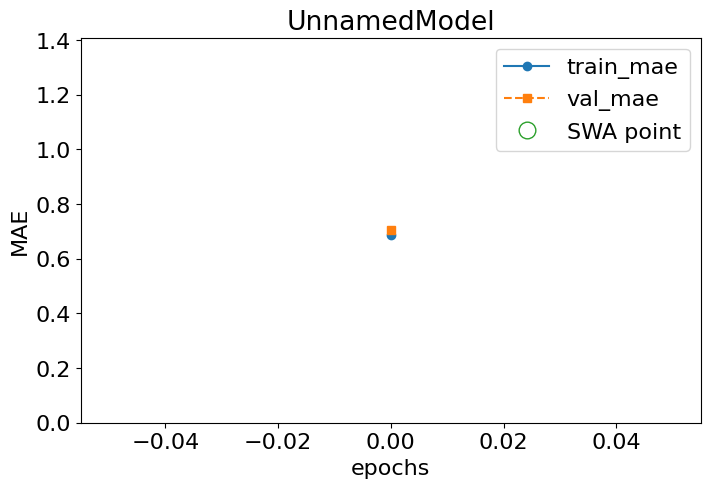

Epoch: 19/300 --- train mae: 0.349 val mae: 0.377


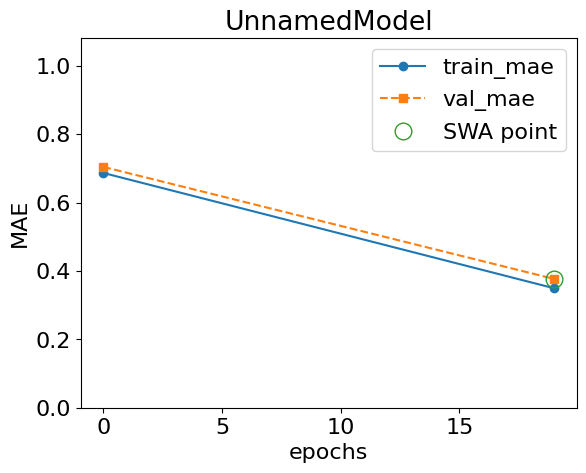

Epoch: 39/300 --- train mae: 0.321 val mae: 0.371


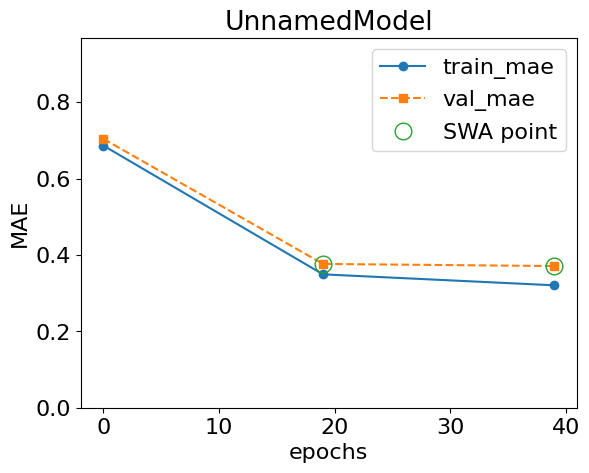

Epoch: 59/300 --- train mae: 0.293 val mae: 0.374


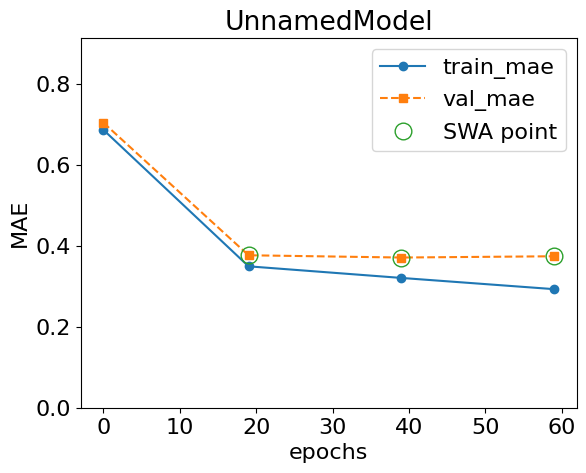

Epoch 79 failed to improve.
Discarded: 1/3 weight updates
Epoch: 79/300 --- train mae: 0.272 val mae: 0.375


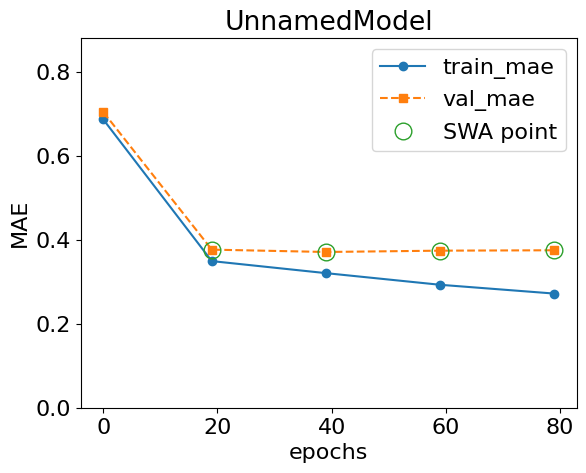

Epoch 99 failed to improve.
Discarded: 2/3 weight updates
Epoch: 99/300 --- train mae: 0.254 val mae: 0.382


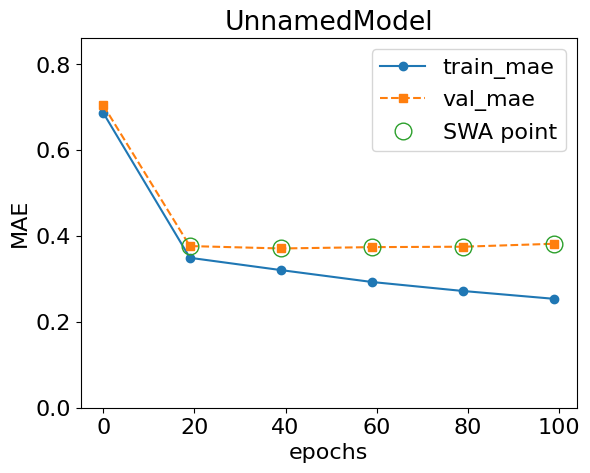

Epoch 119 failed to improve.
Discarded: 3/3 weight updates
Epoch: 119/300 --- train mae: 0.244 val mae: 0.388


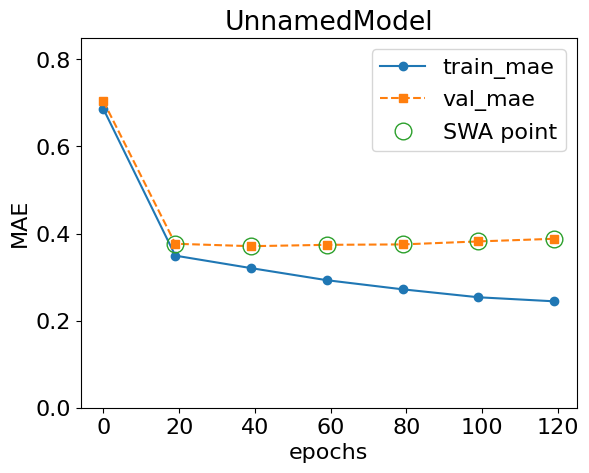

Discarded: 3/3weight updates, early-stopping now
Saving network (UnnamedModel) to models/trained_models/UnnamedModel.pth


In [132]:
cb_onlyTrue.fit(train_TrueLabel)

In [133]:
heldout_toPred_trueLabel = pd.DataFrame({"formula" : heldout_toPred["formula"],
                                "target" : heldout_toPred["target"]})
print(heldout_toPred_trueLabel.shape)
heldout_toPred_trueLabel.head()

(140, 2)


,formula,target
506,Bi6Ru6,0.891019
1817,Re9Tc3,-0.759546
1415,Cu3Pd9,1.301226
500,Bi6Rh6,1.039940
1121,La12,-0.806931


In [134]:
onlyTrue_pred = cb_onlyTrue.predict(heldout_toPred_trueLabel)
heldout_toPred_trueLabel["predicted"] = onlyTrue_pred
heldout_toPred_trueLabel.head()

Generating EDM: 100%|███████████████| 140/140 [00:00<00:00, 351828.98formulae/s]

loading data with up to 7 elements in the formula


,formula,target,count,predicted
506,Bi6Ru6,0.891019,2,0.739282
1817,Re9Tc3,-0.759546,2,-0.564615
1415,Cu3Pd9,1.301226,2,0.799979
500,Bi6Rh6,1.039940,2,0.845961
1121,La12,-0.806931,1,-0.055317


In [177]:
print(type(onlyTrue_pred))

<class 'numpy.ndarray'>


MAE     = 0.303
RMSE    = 0.411
R²      = 0.793
Pearson R = 0.892


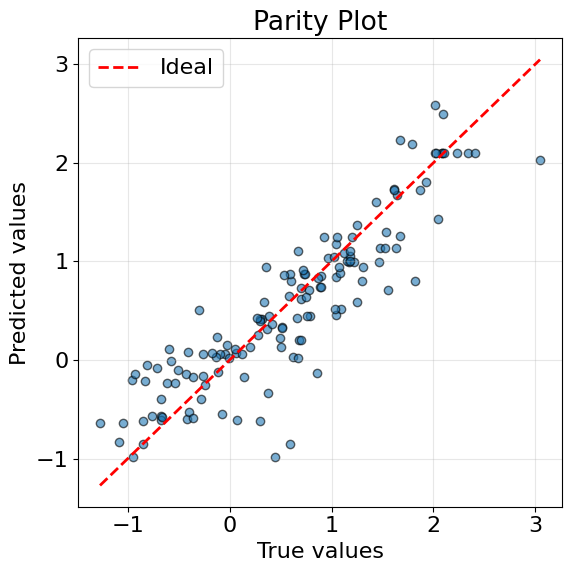

In [135]:
y_true = heldout_toPred_trueLabel["target"].values
y_pred = heldout_toPred_trueLabel["predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [136]:
print("Maximum: ", heldout_toPred_trueLabel["target"].max())
print("Minimum: ", heldout_toPred_trueLabel["target"].min())
print("Mean: ", heldout_toPred_trueLabel["target"].mean())
print("STD: ", heldout_toPred_trueLabel["target"].std())

Maximum:  3.044749469999946
Minimum:  -1.2710359851219577
Mean:  0.5905428631337643
STD:  0.9073220774725311


# Conclusion

### Pseudo labelling does not reduce the MAE relatively to STD, even increase by 3% due to more noise
#### Okay, but what about normal regression model between OH and O

In [146]:
train_df_OH.head()

,formula,load,target
1151,Co36Li18O77,3.294541,1.183651
40,Ag9Cu3,1.442969,0.318513
1280,Os9Pd3,-0.378574,0.168236
2140,Ru6Tc6,-1.080540,-0.648030
52,Ag9Os3,-0.797905,-0.600763


In [150]:
test_df_OH = test_df_OH.drop('count', axis = 1)
test_df_OH = test_df_OH.drop('predicted', axis = 1)

In [163]:
print(test_df_OH.shape)
test_df_OH.head()

(112, 5)


,formula,load,target,predicted,ridge_predicted
958,Ag3Ir9,0.335997,1.025653,0.052772,0.052807
2350,Co9CrFeMnNiZnO20,3.225822,1.827501,1.465967,1.465860
1769,Au3Re9,-1.515123,-1.426799,-0.852470,-0.852345
2185,Ta12,-3.260459,-2.127228,-1.705982,-1.705771
1610,Au3Pt9,1.420026,1.443954,0.582889,0.582870


# Linear Regression for OH* energy

In [152]:
from sklearn.linear_model import LinearRegression

X = train_df_OH[['load']].values  # feature
y = train_df_OH['target'].values   # target

linreg = LinearRegression()
linreg.fit(X, y)

y_pred_linreg = linreg.predict(test_df_OH[['load']])


/opt/anaconda3/envs/crabnet_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [153]:
test_df_OH["predicted"] = y_pred_linreg

MAE     = 0.272
RMSE    = 0.345
R²      = 0.843
Pearson R = 0.920


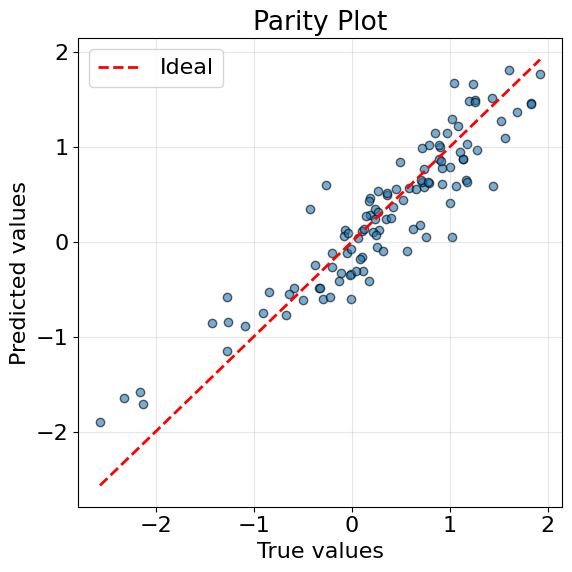

In [154]:
y_true = test_df_OH["target"].values
y_pred = test_df_OH["predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [158]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=0.1)
ridge.fit(X, y)
y_pred_ridge = ridge.predict(test_df_OH[['load']])


/opt/anaconda3/envs/crabnet_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(


In [159]:
test_df_OH["ridge_predicted"] = y_pred_ridge

In [161]:
test_df_OH.head()

,formula,load,target,predicted,ridge_predicted
958,Ag3Ir9,0.335997,1.025653,0.052772,0.052807
2350,Co9CrFeMnNiZnO20,3.225822,1.827501,1.465967,1.465860
1769,Au3Re9,-1.515123,-1.426799,-0.852470,-0.852345
2185,Ta12,-3.260459,-2.127228,-1.705982,-1.705771
1610,Au3Pt9,1.420026,1.443954,0.582889,0.582870


MAE     = 0.272
RMSE    = 0.345
R²      = 0.843
Pearson R = 0.920


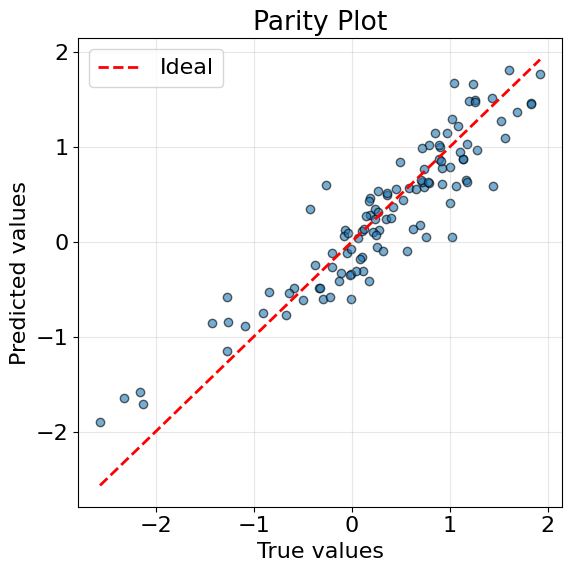

In [160]:
y_true = test_df_OH["target"].values
y_pred = test_df_OH["ridge_predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [164]:
print(true_label_train.shape)
true_label_train.head()

(558, 2)


,formula,target
266,Au9Bi3,0.885535
113,Ag6Bi6,0.920185
752,Cu9Zn3,0.741607
2007,Rh6Zn6,1.842880
1957,Rh9Ru3,0.132928


In [165]:
toPredict_OH.head()

,formula,load,target,count,predicted(OH*)
19,Ag28O16,3.572220,NaN,2,0.19509
20,Ag9Al3,2.246670,NaN,2,0.80133
21,Ag9Al3,2.346134,NaN,2,0.80133
22,Ag9Al3,-0.078674,NaN,2,0.80133
23,Ag9Al3,-0.105450,NaN,2,0.80133


In [166]:
OH_pred_linreg = linreg.predict(toPredict_OH[['load']])

/opt/anaconda3/envs/crabnet_env/lib/python3.9/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [167]:
toPredict_OH["linear_predicted_OH*"] = OH_pred_linreg
toPredict_OH.head()

,formula,load,target,count,predicted(OH*),linear_predicted_OH*
19,Ag28O16,3.572220,NaN,2,0.19509,1.635364
20,Ag9Al3,2.246670,NaN,2,0.80133,0.987138
21,Ag9Al3,2.346134,NaN,2,0.80133,1.035778
22,Ag9Al3,-0.078674,NaN,2,0.80133,-0.150012
23,Ag9Al3,-0.105450,NaN,2,0.80133,-0.163106


In [168]:
lin_pseudo_train = pd.DataFrame({"formula" : toPredict_OH["formula"],
                                "target" : toPredict_OH["load"] - toPredict_OH["linear_predicted_OH*"]})

In [170]:
print(lin_pseudo_train.shape)
lin_pseudo_train.head()

(911, 2)


,formula,target
19,Ag28O16,1.936856
20,Ag9Al3,1.259532
21,Ag9Al3,1.310356
22,Ag9Al3,0.071338
23,Ag9Al3,0.057656


In [171]:
train_lin_pseudo_true = pd.concat([true_label_train, lin_pseudo_train])
print(train_lin_pseudo_true.shape)
train_lin_pseudo_true.head()

(1469, 2)


,formula,target
266,Au9Bi3,0.885535
113,Ag6Bi6,0.920185
752,Cu9Zn3,0.741607
2007,Rh6Zn6,1.842880
1957,Rh9Ru3,0.132928


In [172]:
cb_lin_pseudo_true = CrabNet(
        verbose=True,       # optional, for logging
        learningcurve=False, # optional, skip learning curve plotting
        d_model = 256
)


Model architecture: out_dims, d_model, N, heads
3, 256, 3, 4
Running on compute device: cpu


Model size: 5899526 parameters



Generating EDM: 100%|█████████████| 1175/1175 [00:00<00:00, 327941.66formulae/s]


loading data with up to 7 elements in the formula
training with batchsize 128 (2**7.000)


Generating EDM: 100%|███████████████| 294/294 [00:00<00:00, 393592.52formulae/s]

loading data with up to 7 elements in the formula
stepping every 100 training passes, cycling lr every 10 epochs
running for 300 epochs, unless early stopping occurs
checkin at 20 epochs to match lr scheduler


Epoch: 0/300 --- train mae: 0.711 val mae: 0.708


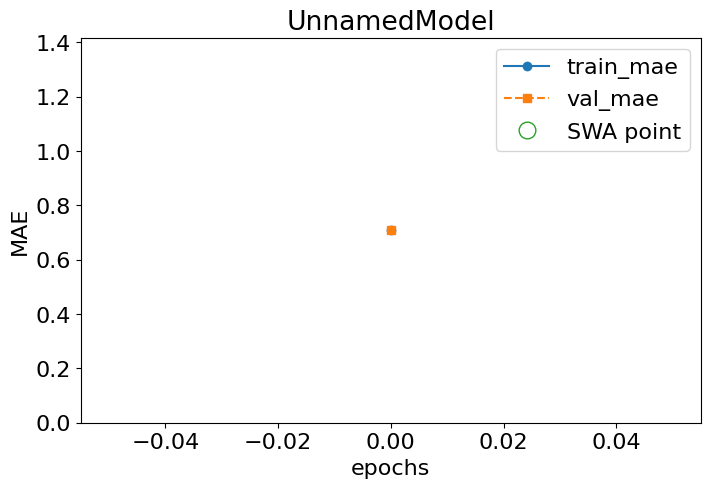

Epoch: 19/300 --- train mae: 0.331 val mae: 0.346


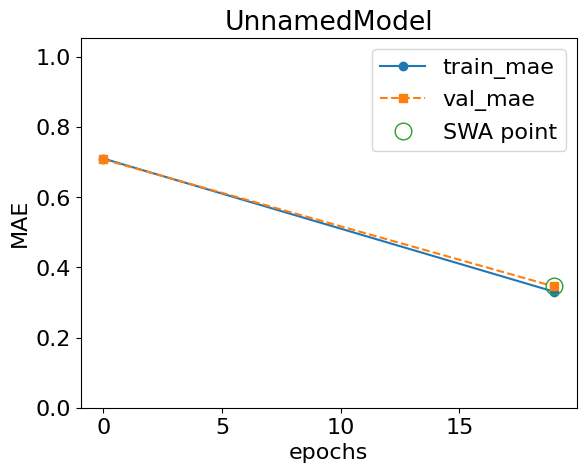

Epoch: 39/300 --- train mae: 0.306 val mae: 0.352


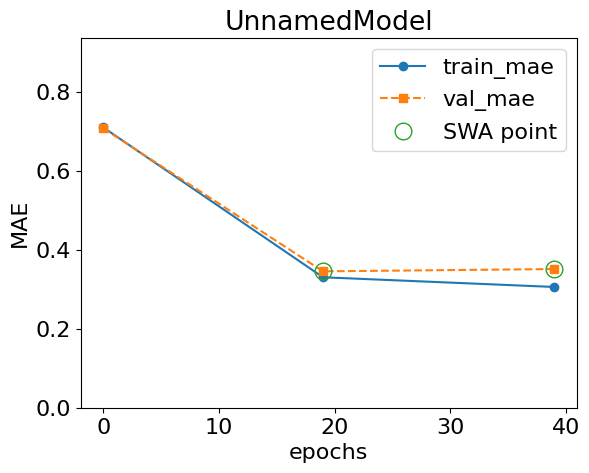

Epoch 59 failed to improve.
Discarded: 1/3 weight updates
Epoch: 59/300 --- train mae: 0.29 val mae: 0.356


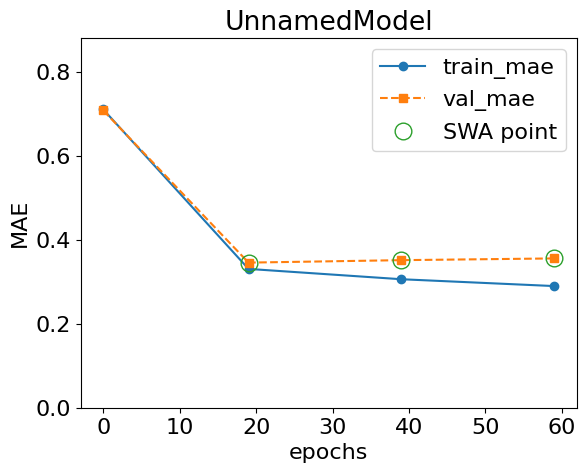

Epoch 79 failed to improve.
Discarded: 2/3 weight updates
Epoch: 79/300 --- train mae: 0.278 val mae: 0.374


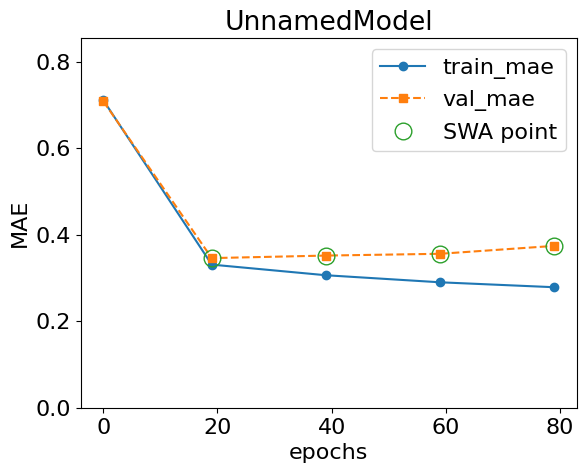

Epoch 99 failed to improve.
Discarded: 3/3 weight updates
Epoch: 99/300 --- train mae: 0.272 val mae: 0.395


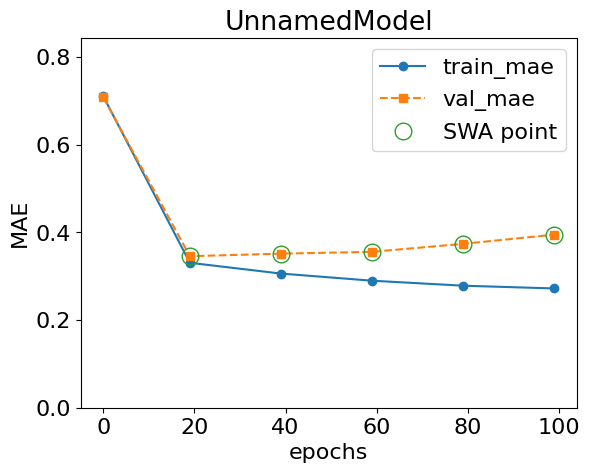

Discarded: 3/3weight updates, early-stopping now
Saving network (UnnamedModel) to models/trained_models/UnnamedModel.pth


In [173]:
cb_lin_pseudo_true.fit(train_lin_pseudo_true)

In [174]:
lin_pseudo_predict = cb_lin_pseudo_true.predict(heldout_toPred_trueLabel)

Generating EDM: 100%|████████████████| 140/140 [00:00<00:00, 94786.53formulae/s]

loading data with up to 7 elements in the formula


In [175]:
heldout_toPred_trueLabel["lin_predicted"] = lin_pseudo_predict
heldout_toPred_trueLabel.head()

,formula,target,count,predicted,lin_predicted
506,Bi6Ru6,0.891019,2,0.739282,0.461594
1817,Re9Tc3,-0.759546,2,-0.564615,-0.460479
1415,Cu3Pd9,1.301226,2,0.799979,0.933756
500,Bi6Rh6,1.039940,2,0.845961,0.677214
1121,La12,-0.806931,1,-0.055317,-0.647196


MAE     = 0.349
RMSE    = 0.495
R²      = 0.700
Pearson R = 0.838


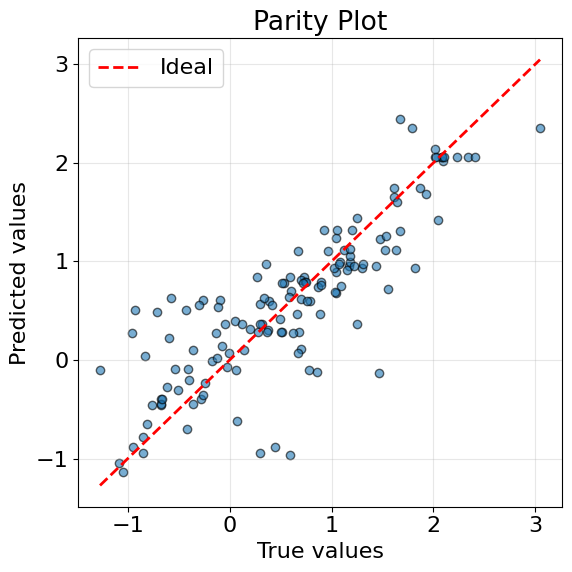

In [176]:
y_true = heldout_toPred_trueLabel["target"].values
y_pred = heldout_toPred_trueLabel["lin_predicted"].values

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
pearson_r, _ = pearsonr(y_true, y_pred)

print(f"MAE     = {mae:.3f}")
print(f"RMSE    = {rmse:.3f}")
print(f"R²      = {r2:.3f}")
print(f"Pearson R = {pearson_r:.3f}")

# --- Parity plot ---
plt.figure(figsize=(6,6))
plt.scatter(y_true, y_pred, alpha=0.6, edgecolor='k')
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', lw=2, label="Ideal")

plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.title("Parity Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [182]:
heldout_true_label.to_csv("fixed_test_set_0.2.csv", index = False)

In [180]:
train_OH_null_afterHeldout.to_csv("fixed_train_set_0.8.csv", index = False)

In [181]:
heldout_true_label.head()

,surfaceComposition,Facet,ChemicalComposition,Site,O*_energy,OH*_energy
506,BiRu,101,Bi6Ru6,top-tilt|B,1.136508,0.245490
1817,Re3Tc,111,Re9Tc3,hollow|A_A_A|HCP,-1.346391,-0.586845
1415,Pd3Cu,111,Cu3Pd9,top|B,2.723777,1.422551
500,BiRh,101,Bi6Rh6,hollow-tilt|A_A_B|FCC,1.462971,0.423030
1121,La,111,La12,hollow|A_A_A|HCP,-2.911750,-2.104819
